# MHC class I epitope similarity

Question: **are epitopes more similar when they share an HLA allele, or when they come from the same source organism?**

Input: `iedb_human_pathogen_working_table.csv` (built in `iedb_working_table.ipynb`).

Scope for this first pass (all toggles in the config cell):
- **MHC class I**, **positive** records only, **unmodified** peptides.
- **9-mers only** — the dominant class I length. Fixing length removes the length confound and lets us use clean per-position metrics (Hamming, BLOSUM62).
- Standard 20 amino acids only (drops peptides with X/U/etc.).

Metrics (fast ones first):
- **Levenshtein** distance (edit distance) — allows shifts (insert/delete).
- **Hamming** distance — position-wise mismatch count; the natural fixed-length metric and most directly tied to per-position (anchor) identity.
- **BLOSUM62 normalized distance** — biochemically aware; `1 - score(p,q)/sqrt(score(p,p)*score(q,q))`, so 0 = identical, larger = more different.

we **sample pairs** rather than build a full matrix.

Note: the source **protein** is known (`source_molecule`), so organism effects can later be separated from same-protein effects.

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import Levenshtein
from Bio.Align import substitution_matrices
from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(0)

# ---- config toggles ----
PEPTIDE_LENGTH   = 9       # focus length
POSITIVE_ONLY    = True
UNMODIFIED_ONLY  = True
N_PAIRS          = 30_000  # sampled pairs per category
MIN_GROUP        = 30      # min unique peptides for a group (allele/species) to be used

## 1. Load & filter

In [55]:
df = pd.read_csv("IEDB/iedb_human_pathogen_working_table_v2.csv", low_memory=False)
print(df.shape)

d = df[df["mhc_class"] == "I"].copy()
if POSITIVE_ONLY:   d = d[d["is_positive"]]
if UNMODIFIED_ONLY: d = d[~d["is_modified"]]
d = d[d["length"] == PEPTIDE_LENGTH]

AA = set("ACDEFGHIKLMNPQRSTVWY")
d = d[d["peptide"].map(lambda p: isinstance(p, str) and set(p) <= AA)]

print(f"Filtered to {d.shape[0]:,} records of length {PEPTIDE_LENGTH} (positive only: {POSITIVE_ONLY}, unmodified only: {UNMODIFIED_ONLY})")


(305861, 18)
Filtered to 60,776 records of length 9 (positive only: True, unmodified only: True)


In [56]:
# normalize allele to 2-field (HLA-A*02:01); drop low-resolution alleles
def norm_allele(a):
    if not isinstance(a, str) or "*" not in a or ":" not in a:
        return None
    locus, rest = a.split("*", 1)
    fields = rest.split(":")
    return f"{locus}*{fields[0]}:{fields[1]}"
d["allele2"] = d["allele"].map(norm_allele)

print(f"class I {PEPTIDE_LENGTH}-mer records: {len(d):,} | unique peptides: {d['peptide'].nunique():,}")
print(f"records with usable 2-field allele: {d['allele2'].notna().sum():,}")
print(f"distinct alleles: {d['allele2'].nunique()} | distinct species: {d['species'].nunique()}")

class I 9-mer records: 60,776 | unique peptides: 20,399
records with usable 2-field allele: 59,630
distinct alleles: 129 | distinct species: 444


In [57]:
d.head(5)

,epitope_iri,peptide,modifications,source_molecule,source_molecule_iri,source_organism,source_organism_iri,species,species_iri,assay_method,qualitative,allele,hla_evidence,mhc_class,length,is_modified,assay_category,is_positive,allele2
0,http://www.iedb.org/epitope/31803,KLEDLERDL,NaN,large delta antigen,http://www.ncbi.nlm.nih.gov/protein/AAG26087.1,Hepatitis delta virus TW2667,https://ontology.iedb.org/ontology/ONTIE_0000432,Hepatitis delta virus,http://purl.obolibrary.org/obo/NCBITaxon_12475,cellular MHC/direct/fluorescence,Positive-Low,HLA-A*02:01,NaN,I,9,False,binding/other,True,HLA-A*02:01
1,http://www.iedb.org/epitope/36724,LITGRLQSL,NaN,Spike glycoprotein,https://www.uniprot.org/uniprot/P59594.1,SARS-CoV1,NaN,SARS-CoV1,https://ontology.iedb.org/taxon/10002316,cellular MHC/direct/fluorescence,Positive-High,HLA-A2,NaN,I,9,False,binding/other,True,None
2,http://www.iedb.org/epitope/14829,EVMPVSMAK,NaN,Spike glycoprotein,https://www.uniprot.org/uniprot/P59594.1,SARS-CoV1,NaN,SARS-CoV1,https://ontology.iedb.org/taxon/10002316,purified MHC/direct/fluorescence,Positive-Intermediate,HLA-A*03:01,NaN,I,9,False,binding/other,True,HLA-A*03:01
3,http://www.iedb.org/epitope/14829,EVMPVSMAK,NaN,Spike glycoprotein,https://www.uniprot.org/uniprot/P59594.1,SARS-CoV1,NaN,SARS-CoV1,https://ontology.iedb.org/taxon/10002316,purified MHC/direct/fluorescence,Positive-High,HLA-A*11:01,NaN,I,9,False,binding/other,True,HLA-A*11:01
4,http://www.iedb.org/epitope/33667,KTFPPTEPK,NaN,Nucleoprotein,https://www.uniprot.org/uniprot/P59595.1,SARS-CoV1,NaN,SARS-CoV1,https://ontology.iedb.org/taxon/10002316,purified MHC/direct/fluorescence,Positive-Intermediate,HLA-A*03:01,NaN,I,9,False,binding/other,True,HLA-A*03:01


## 2. Distance metrics

In [58]:
BL = substitution_matrices.load("BLOSUM62")
_self = {}

def _score(p, q): 
    '''Compute BLOSUM62 score for equal-length peptides p and q. 0 = identical.'''
    return sum(BL[a, b] for a, b in zip(p, q))

def selfscore(p):
    '''Compute BLOSUM62 self-score for peptide p. 0 = identical.'''
    s = _self.get(p)
    if s is None:
        s = _self[p] = _score(p, p)
    return s

# levenstein and hamming distances could be redundant if string length is fixed, 
# but they are not always equal for non-identical strings
# except it can still find cheaper alignments via a shift+indel combo 
# (e.g. ABCDE vs BCDEF is Levenshtein 2 but Hamming 5). 
def lev(p, q):
    return Levenshtein.distance(p, q)

# A peptide sits in the MHC groove anchored at fixed positions (typically P2 and P9 for many HLA-I alleles), 
# and TCR recognition is position-specific. 
def hamming(p, q):
    """Position-wise mismatch count. Assumes equal length (true here: fixed 9-mers).
    Unlike Levenshtein it does not allow shifts, so it directly reflects per-position identity."""
    return Levenshtein.hamming(p, q)

def blosum_dist(p, q):
    """Normalized BLOSUM62 distance for equal-length peptides. 0 = identical.
    kernel-normalization used in string kernels (local-alignment kernels; 
    the general form K(p,q)/sqrt(K(p,p)K(q,q))). 
    """
    d = 1.0 - _score(p, q) / np.sqrt(selfscore(p) * selfscore(q))
    return max(d, 0.0)


In [59]:
# sanity check
print("identical :", 'lev: ', lev('SIINFEKL','SIINFEKL'), '- hamming: ', hamming('SIINFEKL','SIINFEKL'), ' - blosum: ', round(blosum_dist('SIINFEKL','SIINFEKL'),3))

print("1 conserv.:", 'lev: ', lev('SIINFEKL','SIINFEKI'), '- hamming: ', hamming('SIINFEKL','SIINFEKI'), ' - blosum: ', round(blosum_dist('SIINFEKL','SIINFEKI'),3))
print("2 conserv.:", 'lev: ', lev('SIIAFEKL','SIINFEKI'), '- hamming: ', hamming('SIIAFEKL','SIINFEKI'), ' - blosum: ', round(blosum_dist('SIIAFEKL','SIINFEKI'),3))

print("1 radical :", 'lev: ', lev('SIINFEKL','SIINFEKD'), '- hamming: ', hamming('SIINFEKL','SIINFEKD'), ' - blosum: ', round(blosum_dist('SIINFEKL','SIINFEKD'),3))
print("shifted   :", 'lev: ', lev('SIINFEKLA','IINFEKLAS'), '- hamming: ', hamming('SIINFEKLA','IINFEKLAS'), ' - blosum: ', round(blosum_dist('SIINFEKLA','IINFEKLAS'),3))

print("deleted   :", 'lev: ', lev('IINFEKLA','IINFEKLAS'), '- hamming: ', hamming('IINFEKLA','IINFEKLAS'), ' - blosum: ', round(blosum_dist('IINFEKLA','IINFEKLAS'),3))

identical : lev:  0 - hamming:  0  - blosum:  0.0
1 conserv.: lev:  1 - hamming:  1  - blosum:  0.053
2 conserv.: lev:  2 - hamming:  2  - blosum:  0.243
1 radical : lev:  1 - hamming:  1  - blosum:  0.231
shifted   : lev:  2 - hamming:  8  - blosum:  1.19
deleted   : lev:  1 - hamming:  1  - blosum:  0.049


## 3. Pair sampling helpers

In [60]:
def build_groups(frame, key, min_size=MIN_GROUP):
    """
    This function buckets peptides by some grouping column and returns only the buckets large enough to be useful.
    Parameters
    ----------
    key -> np.array of unique peptides, keeping groups with >= min_size peptides.
    min_size -> int, minimum number of peptides required for a group to be included.
    """
    g = (frame.dropna(subset=[key])
              .groupby(key)["peptide"].unique())
    return {k: np.array(v) for k, v in g.items() if len(v) >= min_size}

def sample_within(groups, n):
    '''
    Sample n pairs of peptides from within the same group.
    draws n random within-group peptide pairs — two distinct peptides that share the same key (e.g. the same HLA allele).
    n is the total number of pairs to sample, and groups are revisited with replacement, so a popular group can contribute multiple pairs.
    Parameters
    ----------
    groups -> dict of {group: np.array of peptides}
    n -> int, number of pairs to sample
    Returns
    -------
    list of n tuples of peptide pairs
    '''
    keys = list(groups)  # list of group keys (e.g. alleles)
    # samples n group keys "with replacement", and takes one pair per pick — so you get n pairs total, spread across groups. 
    # A popular allele gets revisited multiple times across the n picks,
    pick = rng.choice(len(keys), size=n) 
    pairs = []
    for i in pick:
        v = groups[keys[i]]
        a, b = rng.choice(len(v), size=2, replace=False)
        pairs.append((v[a], v[b]))
    return pairs


def sample_between(groups, n):
    keys = list(groups)
    ii = rng.integers(0, len(keys), size=n * 2) ## over sampled to avoid duplicates, since we skip pairs where i==j
    jj = rng.integers(0, len(keys), size=n * 2)
    pairs = []
    for i, j in zip(ii, jj):
        if i == j:
            continue
        a = groups[keys[i]]
        b = groups[keys[j]]

        pa = a[rng.integers(len(a))]
        pb = b[rng.integers(len(b))]

        if pa != pb:
            pairs.append((pa, pb))
        if len(pairs) >= n:
            break
    return pairs

def dists(pairs, metric):
    return np.fromiter((metric(a, b) for a, b in pairs), dtype=float, count=len(pairs))

#METRICS = [("Levenshtein", lev), ("Hamming", hamming), ("BLOSUM62", blosum_dist)]
METRICS = [("Hamming", hamming)]



def compare(wp, bp, label):
    rows = []
    for mname, metric in METRICS:
        for grp, pairs in [("within", wp), ("between", bp)]:
            for v in dists(pairs, metric):
                rows.append({"grouping": label, "metric": mname, "pair": grp, "distance": v})
    return pd.DataFrame(rows)

## 4. Similarity by HLA allele

Within-allele = two peptides presented by the **same** HLA allele; between-allele = peptides from **different** alleles. If anchor motifs drive similarity, within-allele distances should be clearly smaller.

In [61]:
allele_groups = build_groups(d, "allele2")
print(len(allele_groups))
print(allele_groups['HLA-A*01:01'][1:5])
print(len(allele_groups['HLA-A*01:01']))

79
['CTDDNALAY' 'LTDDMIAAY' 'KSDGTGTIY' 'ISDYDYYRY']
1039


count      79.000000
mean      561.835443
std       891.510421
min        31.000000
25%        99.000000
50%       284.000000
75%       605.500000
max      6603.000000
dtype: float64


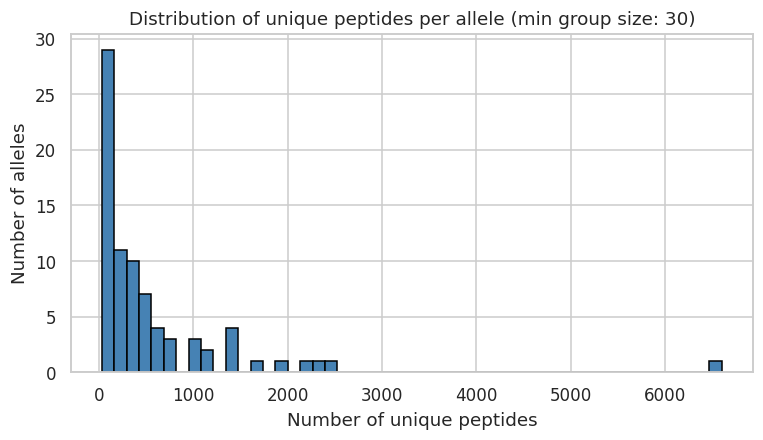

In [62]:
### make a histogram of the number of unique peptides per allele
plt.figure(figsize=(8, 4))
allele_sizes = [len(v) for v in allele_groups.values()]
plt.hist(allele_sizes, bins=50, color="steelblue", edgecolor="black")
plt.title(f"Distribution of unique peptides per allele (min group size: {MIN_GROUP})")
plt.xlabel("Number of unique peptides")
plt.ylabel("Number of alleles")


print(pd.Series(allele_sizes).describe())

In [63]:
allele_groups = build_groups(d, "allele2")


In [64]:
print(f"alleles used (>= {MIN_GROUP} peptides): {len(allele_groups)}")

alleles used (>= 30 peptides): 79


One iteration of sampling:

In [65]:
total_samples = 1000000
wp = sample_within(groups=allele_groups, n=total_samples)
bp = sample_between(groups=allele_groups, n=total_samples)

wp_dists = dists(wp, hamming)
bp_dists = dists(bp, hamming)

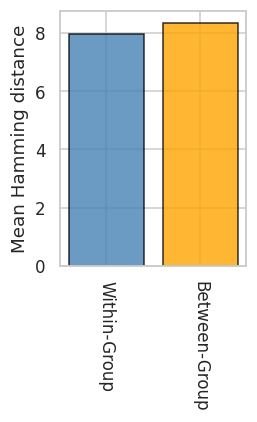

In [72]:
### make a paried bar plot of the within-group and between-group distances
plt.figure(figsize=(2.5, 4))
plt.bar(["Within-Group", "Between-Group"], [wp_dists.mean(), bp_dists.mean()], color=["steelblue", "orange"], alpha=0.8, edgecolor="black")
plt.ylabel("Mean Hamming distance")
plt.xticks(rotation=-90)
plt.tight_layout()
plt.show()

In [73]:
res_allele = compare(wp=wp, bp=bp, label="HLA allele")
res_allele.groupby(["metric", "pair"])["distance"].describe()[["mean", "50%", "std"]]

mean  50%       std
metric  pair                            
Hamming between  8.351740  9.0  0.782456
        within   7.963213  8.0  0.949086

### Sampling n_iter times and then visualizing the results

In [ ]:
rows = []
n_iter = 10
for it in range(n_iter):
    wp = sample_within(groups=allele_groups, n=total_samples)
    bp = sample_between(groups=allele_groups, n=total_samples)
    for pair_lbl, d in [("within", dists(wp, hamming)), ("between", dists(bp, hamming))]:
        rows.append(pd.DataFrame({"iter": it, "pair": pair_lbl, "distance": d}))
res_iters = pd.concat(rows, ignore_index=True)


In [74]:
print(f"res_iters shape: {res_iters.shape} | unique iterations: {res_iters['iter'].nunique()} | unique pair types: {res_iters['pair'].nunique()}")
# e.g. mean distance per iteration and pair type
res_iters.groupby(["pair", "iter"])["distance"].mean().unstack("pair")

res_iters shape: (20000000, 3) | unique iterations: 10 | unique pair types: 2


pair,between,within
iter,,
0,8.351520,7.964152
1,8.351977,7.963701
2,8.351175,7.965337
3,8.351794,7.966078
4,8.350240,7.965462
5,8.350896,7.963646
6,8.350963,7.963834
7,8.350922,7.962742
8,8.351738,7.963124


/tmp/ipykernel_1040689/1813152428.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=iter_means, x="pair", y="mean_distance", order=order,


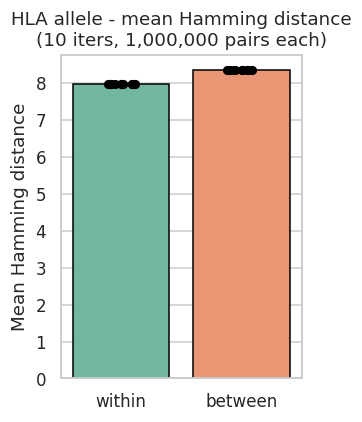

In [76]:
# barplot of mean Hamming distance per pair type, one dot per iteration
iter_means = (res_iters.groupby(["pair", "iter"])["distance"]
                       .mean().reset_index(name="mean_distance"))

order = ["within", "between"]
fig, ax = plt.subplots(figsize=(3, 4))
sns.barplot(data=iter_means, x="pair", y="mean_distance", order=order,
            palette="Set2", errorbar="sd", capsize=0.15, ax=ax, edgecolor="black")   # bar = mean over iters, whisker = SD
sns.stripplot(data=iter_means, x="pair", y="mean_distance", order=order,
              color="black", size=6, jitter=0.12, ax=ax)          # one dot per iteration

ax.set(title=f"HLA allele - mean Hamming distance\n({n_iter} iters, {total_samples:,} pairs each)",
       xlabel="", ylabel="Mean Hamming distance")
plt.tight_layout(); 
plt.show()

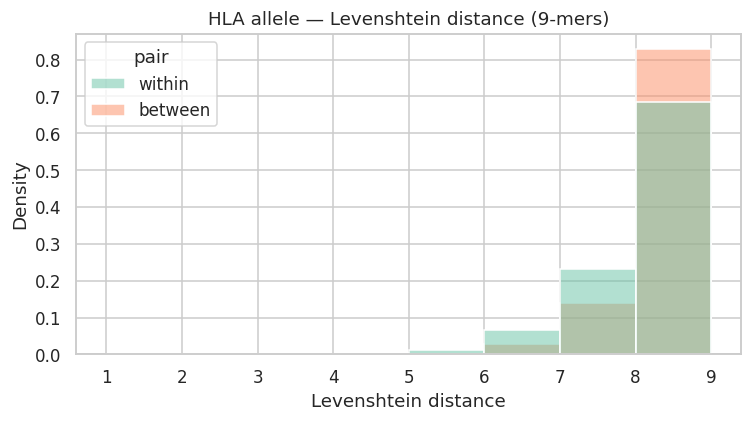

In [6]:
# Levenshtein: within vs between allele
sub = res_allele[res_allele["metric"] == "Levenshtein"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=sub, x="distance", hue="pair", binwidth=1, stat="density",
             common_norm=False, palette="Set2", ax=ax)
ax.set(title="HLA allele — Levenshtein distance (9-mers)", xlabel="Levenshtein distance")
plt.tight_layout(); plt.show()

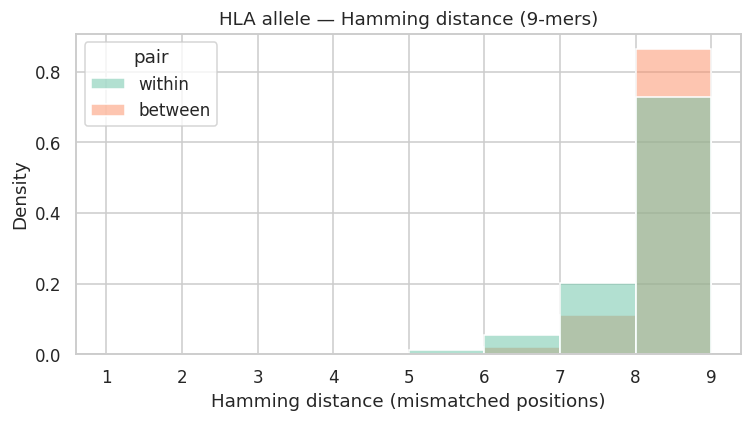

In [7]:
# Hamming: within vs between allele
sub = res_allele[res_allele["metric"] == "Hamming"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=sub, x="distance", hue="pair", binwidth=1, stat="density",
             common_norm=False, palette="Set2", ax=ax)
ax.set(title="HLA allele — Hamming distance (9-mers)", xlabel="Hamming distance (mismatched positions)")
plt.tight_layout(); plt.show()

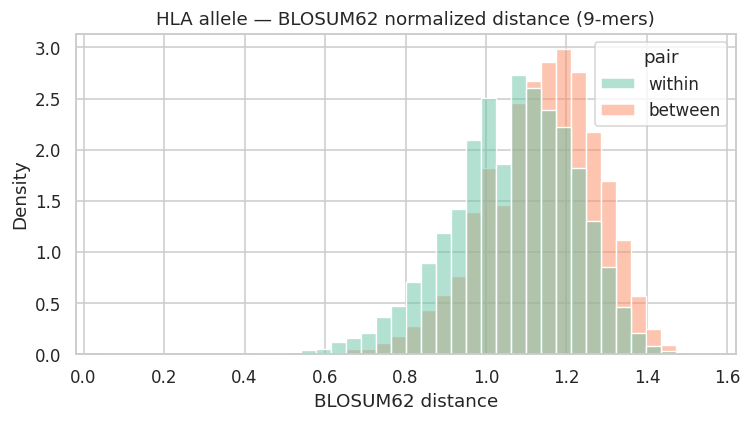

In [8]:
# BLOSUM62: within vs between allele
sub = res_allele[res_allele["metric"] == "BLOSUM62"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=sub, x="distance", hue="pair", bins=40, stat="density",
             common_norm=False, palette="Set2", ax=ax)
ax.set(title="HLA allele — BLOSUM62 normalized distance (9-mers)", xlabel="BLOSUM62 distance")
plt.tight_layout(); plt.show()

## 5. Similarity by source organism

In [9]:
species_groups = build_groups(d, "species")
print(f"species used (>= {MIN_GROUP} peptides): {len(species_groups)}")
res_species = compare(species_groups, "source organism")
res_species.groupby(["metric", "pair"])["distance"].describe()[["mean", "50%", "std"]]

species used (>= 30 peptides): 76


mean       50%       std
metric      pair                                 
BLOSUM62    between  1.151995  1.165027  0.139353
            within   1.130747  1.146385  0.152433
Hamming     between  8.359700  9.000000  0.778933
            within   8.247967  8.000000  0.875236
Levenshtein between  8.234233  8.000000  0.819506
            within   8.095233  8.000000  0.938826

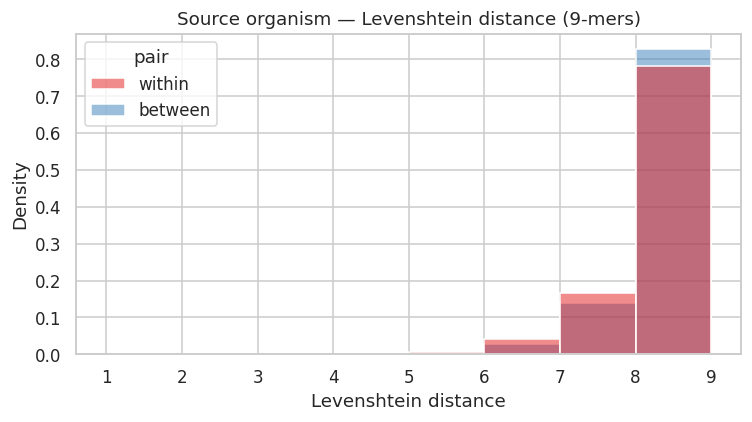

In [10]:
# Levenshtein: within vs between organism
sub = res_species[res_species["metric"] == "Levenshtein"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=sub, x="distance", hue="pair", binwidth=1, stat="density",
             common_norm=False, palette="Set1", ax=ax)
ax.set(title="Source organism — Levenshtein distance (9-mers)", xlabel="Levenshtein distance")
plt.tight_layout(); plt.show()

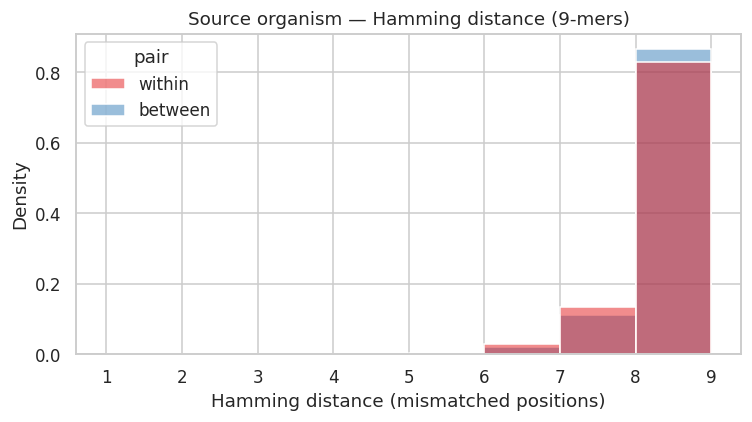

In [11]:
# Hamming: within vs between organism
sub = res_species[res_species["metric"] == "Hamming"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=sub, x="distance", hue="pair", binwidth=1, stat="density",
             common_norm=False, palette="Set1", ax=ax)
ax.set(title="Source organism — Hamming distance (9-mers)", xlabel="Hamming distance (mismatched positions)")
plt.tight_layout(); plt.show()

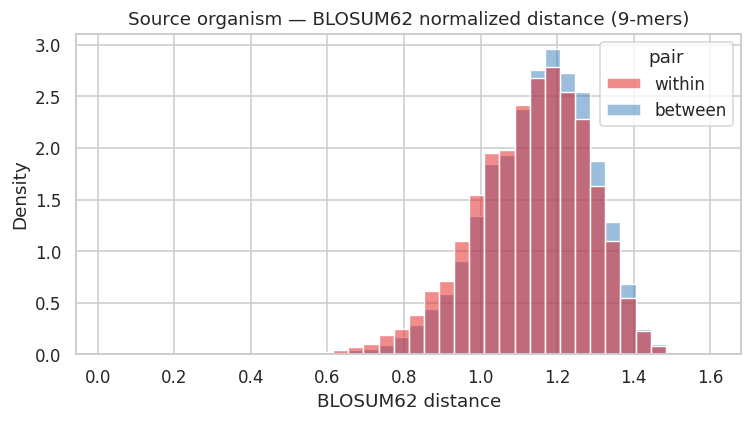

In [12]:
# BLOSUM62: within vs between organism
sub = res_species[res_species["metric"] == "BLOSUM62"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=sub, x="distance", hue="pair", bins=40, stat="density",
             common_norm=False, palette="Set1", ax=ax)
ax.set(title="Source organism — BLOSUM62 normalized distance (9-mers)", xlabel="BLOSUM62 distance")
plt.tight_layout(); plt.show()

## 5b. Similarity by source protein

Grouping key = `source_molecule_iri` (UniProt/NCBI accession — cleaner than the free-text protein name, since the same name maps to several accessions across strains). Expectation: same-protein peptides are overlapping/adjacent windows of one sequence, so this should show a **much larger** within-group effect than organism — and is the main confound behind the organism signal.

In [13]:
protein_groups = build_groups(d, "source_molecule_iri")
print(f"proteins used (>= {MIN_GROUP} peptides): {len(protein_groups)}")
res_protein = compare(protein_groups, "source protein")
res_protein.groupby(["metric", "pair"])["distance"].describe()[["mean", "50%", "std"]]

proteins used (>= 30 peptides): 115


mean       50%       std
metric      pair                                 
BLOSUM62    between  1.152399  1.165009  0.137455
            within   1.128873  1.141421  0.146534
Hamming     between  8.389133  9.000000  0.760216
            within   8.272933  8.000000  0.826477
Levenshtein between  8.257733  8.000000  0.804443
            within   8.063133  8.000000  1.015406

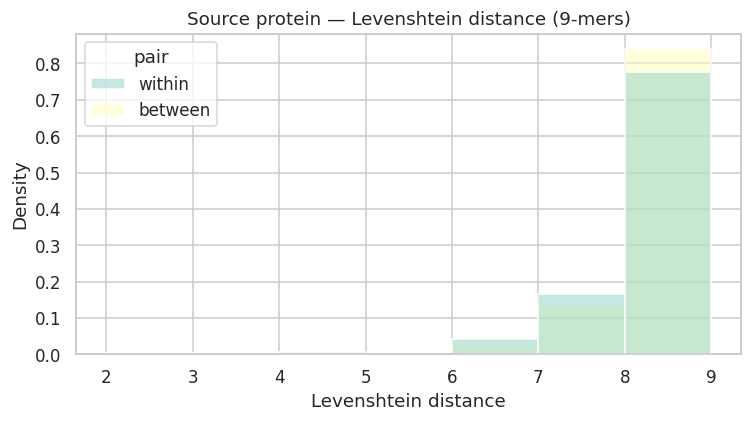

In [14]:
# Levenshtein: within vs between protein
sub = res_protein[res_protein["metric"] == "Levenshtein"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=sub, x="distance", hue="pair", binwidth=1, stat="density",
             common_norm=False, palette="Set3", ax=ax)
ax.set(title="Source protein — Levenshtein distance (9-mers)", xlabel="Levenshtein distance")
plt.tight_layout(); plt.show()

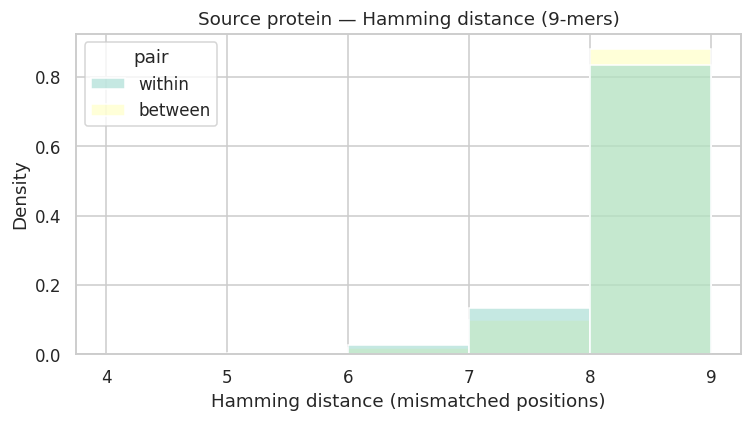

In [15]:
# Hamming: within vs between protein
sub = res_protein[res_protein["metric"] == "Hamming"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=sub, x="distance", hue="pair", binwidth=1, stat="density",
             common_norm=False, palette="Set3", ax=ax)
ax.set(title="Source protein — Hamming distance (9-mers)", xlabel="Hamming distance (mismatched positions)")
plt.tight_layout(); plt.show()

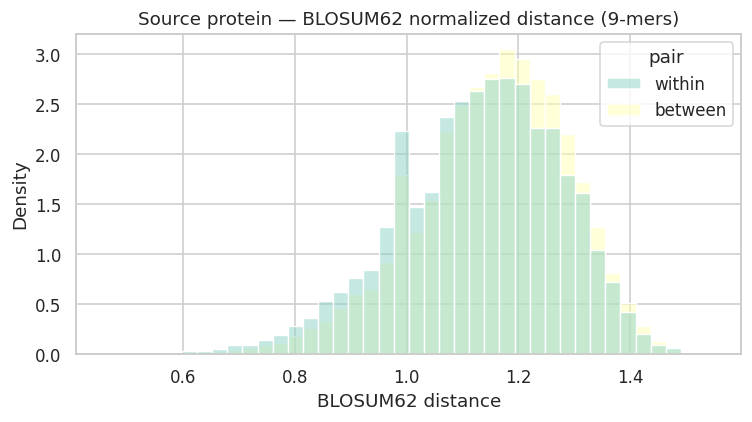

In [16]:
# BLOSUM62: within vs between protein
sub = res_protein[res_protein["metric"] == "BLOSUM62"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=sub, x="distance", hue="pair", bins=40, stat="density",
             common_norm=False, palette="Set3", ax=ax)
ax.set(title="Source protein — BLOSUM62 normalized distance (9-mers)", xlabel="BLOSUM62 distance")
plt.tight_layout(); plt.show()

## 5c. De-confounded organism effect (hold HLA fixed, exclude same-protein)

The raw organism effect mixes three things: HLA skew, shared source protein, and any genuine pathogen-level signal. Here we isolate the last one:

- **within-organism**: two peptides from the **same** species, presented by the **same** allele, but from **different** proteins.
- **between-organism**: two peptides from **different** species, presented by the **same** allele.

If within is still meaningfully smaller than between, there is a real same-pathogen signal beyond allele and protein. If they coincide, the earlier organism effect was just allele + protein.

In [17]:
N_CTRL = 20_000

# unique (peptide, allele, species, protein) rows; index per allele as numpy arrays for speed
ctrl = (d.dropna(subset=["allele2", "species", "source_molecule_iri"])
          [["peptide", "allele2", "species", "source_molecule_iri"]]
          .drop_duplicates())
by_allele = {a: (s["peptide"].to_numpy(), s["species"].to_numpy(), s["source_molecule_iri"].to_numpy())
             for a, s in ctrl.groupby("allele2")}
alleles_multi = [a for a, (p, sp, pr) in by_allele.items() if len(set(sp)) >= 2]
print(f"alleles spanning >=2 species: {len(alleles_multi)}")

def sample_within_org_diff_protein(n):
    pairs = []; tries = 0; maxt = n * 80
    while len(pairs) < n and tries < maxt:
        tries += 1
        pep, sp, pr = by_allele[alleles_multi[rng.integers(len(alleles_multi))]]
        i = rng.integers(len(pep))
        idx = np.flatnonzero((sp == sp[i]) & (pr != pr[i]))  # same species, different protein
        if idx.size == 0:
            continue
        j = idx[rng.integers(idx.size)]
        if pep[i] != pep[j]:
            pairs.append((pep[i], pep[j]))
    return pairs

def sample_between_org_same_allele(n):
    pairs = []; tries = 0; maxt = n * 80
    while len(pairs) < n and tries < maxt:
        tries += 1
        pep, sp, pr = by_allele[alleles_multi[rng.integers(len(alleles_multi))]]
        i, j = rng.integers(len(pep)), rng.integers(len(pep))
        if sp[i] != sp[j] and pep[i] != pep[j]:   # different species
            pairs.append((pep[i], pep[j]))
    return pairs

wp = sample_within_org_diff_protein(N_CTRL)
bp = sample_between_org_same_allele(N_CTRL)
print(f"sampled pairs -> within: {len(wp):,} | between: {len(bp):,}")

rows = []
for mname, metric in METRICS:
    for grp, pairs in [("within-org\n(same allele, diff protein)", wp), ("between-org\n(same allele)", bp)]:
        for v in dists(pairs, metric):
            rows.append({"metric": mname, "pair": grp, "distance": v})
res_ctrl = pd.DataFrame(rows)
res_ctrl.groupby(["metric", "pair"])["distance"].describe()[["mean", "50%", "std"]]

alleles spanning >=2 species: 104


sampled pairs -> within: 20,000 | between: 20,000


mean       50%  \
metric      pair                                                          
BLOSUM62    between-org\n(same allele)               1.054632  1.063415   
            within-org\n(same allele, diff protein)  1.020730  1.044969   
Hamming     between-org\n(same allele)               7.873350  8.000000   
            within-org\n(same allele, diff protein)  7.644650  8.000000   
Levenshtein between-org\n(same allele)               7.772800  8.000000   
            within-org\n(same allele, diff protein)  7.506450  8.000000   

                                                          std  
metric      pair                                               
BLOSUM62    between-org\n(same allele)               0.162918  
            within-org\n(same allele, diff protein)  0.206081  
Hamming     between-org\n(same allele)               1.017527  
            within-org\n(same allele, diff protein)  1.359216  
Levenshtein between-org\n(same allele)               1.019918  
            within-org\n(same allele, diff protein)  1.375556

In [18]:
# effect size for the de-confounded comparison
within_lbl = "within-org\n(same allele, diff protein)"
between_lbl = "between-org\n(same allele)"
ctrl_summary = []
for mname in ["Levenshtein", "Hamming", "BLOSUM62"]:
    s = res_ctrl[res_ctrl["metric"] == mname]
    w = s[s["pair"] == within_lbl]["distance"]
    b = s[s["pair"] == between_lbl]["distance"]
    u, p = mannwhitneyu(w, b, alternative="less")
    ctrl_summary.append({"metric": mname,
                         "mean_within": round(w.mean(), 3), "mean_between": round(b.mean(), 3),
                         "ratio": round(w.mean() / b.mean(), 3), "p(within<between)": f"{p:.1e}"})
pd.DataFrame(ctrl_summary)

,metric,mean_within,mean_between,ratio,p(within<between)
0,Levenshtein,7.506,7.773,0.966,8.4e-64
1,Hamming,7.645,7.873,0.971,2.0e-46
2,BLOSUM62,1.021,1.055,0.968,1.9e-39


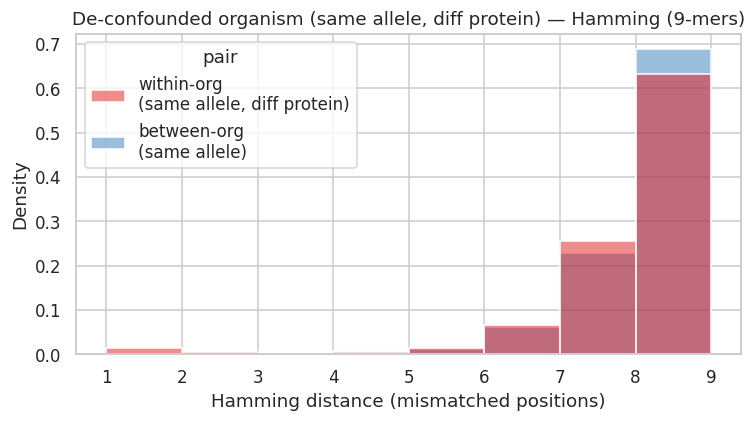

In [19]:
# De-confounded organism: Hamming distance (fast, position-wise)
sub = res_ctrl[res_ctrl["metric"] == "Hamming"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=sub, x="distance", hue="pair", binwidth=1, stat="density",
             common_norm=False, palette="Set1", ax=ax)
ax.set(title="De-confounded organism (same allele, diff protein) — Hamming (9-mers)",
       xlabel="Hamming distance (mismatched positions)")
plt.tight_layout(); plt.show()

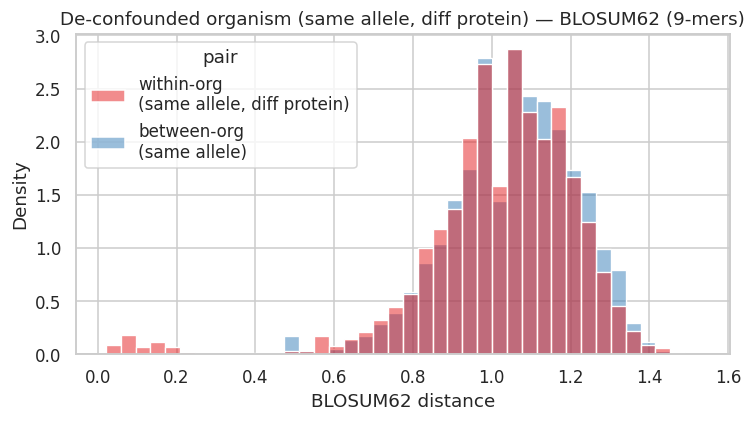

In [20]:
# De-confounded organism: BLOSUM62 distance
sub = res_ctrl[res_ctrl["metric"] == "BLOSUM62"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=sub, x="distance", hue="pair", bins=40, stat="density",
             common_norm=False, palette="Set1", ax=ax)
ax.set(title="De-confounded organism (same allele, diff protein) — BLOSUM62 (9-mers)",
       xlabel="BLOSUM62 distance")
plt.tight_layout(); plt.show()

## 6. Side-by-side effect sizes

How much smaller are within-group distances than between-group, for allele vs organism? (Mean within / mean between; lower ratio = stronger grouping effect.)

In [21]:
summary = []
for res in [res_allele, res_species, res_protein]:
    label = res["grouping"].iloc[0]
    for mname in ["Levenshtein", "Hamming", "BLOSUM62"]:
        s = res[res["metric"] == mname]
        w = s[s["pair"] == "within"]["distance"]
        b = s[s["pair"] == "between"]["distance"]
        u, p = mannwhitneyu(w, b, alternative="less")
        summary.append({"grouping": label, "metric": mname,
                        "mean_within": round(w.mean(), 3), "mean_between": round(b.mean(), 3),
                        "ratio": round(w.mean() / b.mean(), 3), "p(within<between)": f"{p:.1e}"})
summary_df = pd.DataFrame(summary)
summary_df

,grouping,metric,mean_within,mean_between,ratio,p(within<between)
0,HLA allele,Levenshtein,7.857,8.227,0.955,0.0e+00
1,HLA allele,Hamming,7.969,8.344,0.955,0.0e+00
2,HLA allele,BLOSUM62,1.066,1.138,0.937,0.0e+00
3,source organism,Levenshtein,8.095,8.234,0.983,1.5e-65
4,source organism,Hamming,8.248,8.360,0.987,1.6e-49
5,source organism,BLOSUM62,1.131,1.152,0.982,9.9e-56
6,source protein,Levenshtein,8.063,8.258,0.976,2.8e-105
7,source protein,Hamming,8.273,8.389,0.986,2.8e-65
8,source protein,BLOSUM62,1.129,1.152,0.980,3.5e-84


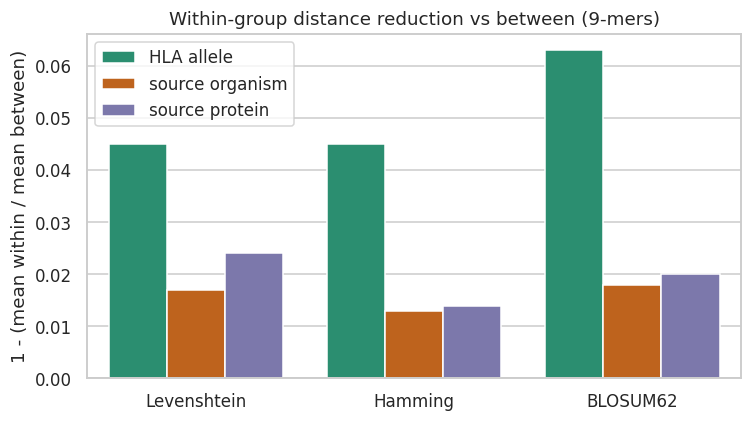

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_df = summary_df.assign(reduction=1 - summary_df["ratio"])
sns.barplot(data=plot_df, x="metric", y="reduction", hue="grouping", palette="Dark2", ax=ax)
ax.set(title="Within-group distance reduction vs between (9-mers)",
       ylabel="1 - (mean within / mean between)", xlabel="")
ax.legend(title="")
plt.tight_layout(); plt.show()

## 7. Notes / next steps

- **Confound to address next:** the organism effect is contaminated by **shared source protein** (many epitopes of one pathogen come from one polyprotein) and by **HLA** (a pathogen's epitopes skew toward common alleles). Next iteration: recompute the organism within-vs-between while holding **allele fixed** and excluding same-protein pairs.
- Extend beyond 9-mers (10/11-mers) using Levenshtein / alignment-based BLOSUM for unequal lengths.
- Consider an allele-vs-allele and organism-vs-organism mean-distance heatmap to see which alleles/pathogens cluster.